Visualising Distributions

Amani Insurance claims case study

Deliverable: Visualising distributions using Matplotlib and Seaborn.

In [7]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

FILE_PATH = "insurance_claims_messy.csv"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")  # a clean, readable default look for every Seaborn chart


def save_and_show(fig, name):
    """Save a Matplotlib figure to plots/ and display it inline."""
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, dpi=120, bbox_inches="tight")
    print(f"saved -> {path}")
    plt.show()
    plt.close(fig)

In [8]:
# Same light cleaning as Part 1: make claim_amount_kes numeric, and
# canonicalise claim_type/status just enough for grouping and colouring.
df = pd.read_csv(FILE_PATH)
df["claim_amount_kes"] = (
    df["claim_amount_kes"].astype(str).str.replace(",", "", regex=False).str.strip()
)
df["claim_amount_kes"] = pd.to_numeric(df["claim_amount_kes"], errors="coerce")
df["claim_type_clean"] = (
    df["claim_type"].astype(str).str.strip().str.lower().str.replace(" ", "-")
)
df["status_clean"] = df["status"].astype(str).str.strip().str.lower()

# usable: only claims with a valid, positive amount -- charts about SIZE
# of claims need a real number to plot.
usable = df[df["claim_amount_kes"] > 0].copy()


A basic Matplotlib histogram


A histogram groups values into "bins" (ranges) and counts how many claims fall into each one — the classic way to see a distribution's overall shape.

saved -> plots/01_matplotlib_histogram.png


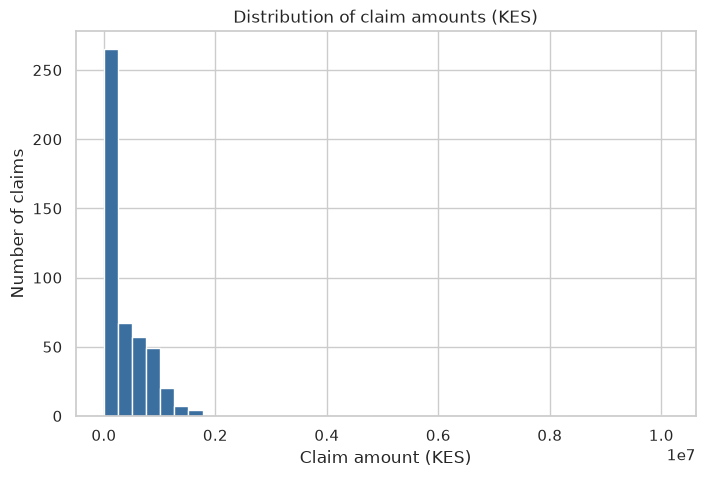

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(usable["claim_amount_kes"], bins=40, color="#3b6fa0", edgecolor="white")
ax.set_title("Distribution of claim amounts (KES)")
ax.set_xlabel("Claim amount (KES)")
ax.set_ylabel("Number of claims")
save_and_show(fig, "01_matplotlib_histogram.png")

The same distribution, log-scaled x-axis

A log scale spaces out small and large values more evenly, revealing detail that the linear version hides.

saved -> plots/02_matplotlib_histogram_logscale.png


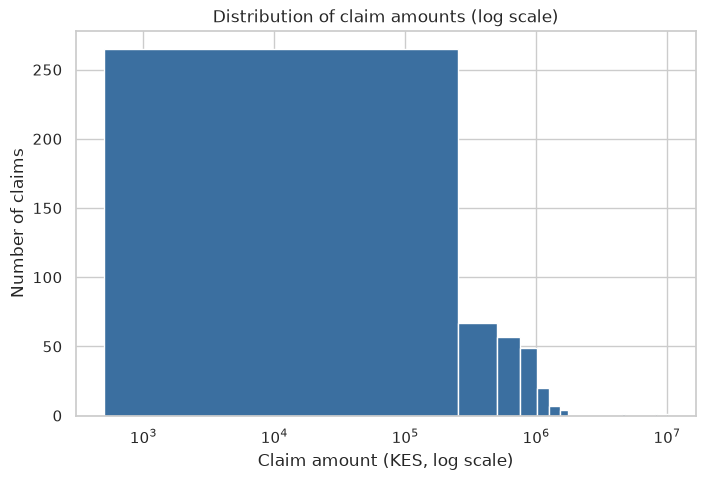

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(usable["claim_amount_kes"], bins=40, color="#3b6fa0", edgecolor="white")
ax.set_xscale("log")   # the only change from Section 1 -- log-scale the x-axis
ax.set_title("Distribution of claim amounts (log scale)")
ax.set_xlabel("Claim amount (KES, log scale)")
ax.set_ylabel("Number of claims")
save_and_show(fig, "02_matplotlib_histogram_logscale.png")



Seaborn: distributions split by claim type



Seaborn is built on top of Matplotlib, but handles a lot of the fiddly work (colours, legends, grouping) automatically. Here we overlay one distribution curve per claim type, on log-scaled axes, in a handful of lines.

saved -> plots/03_seaborn_histplot_by_type.png


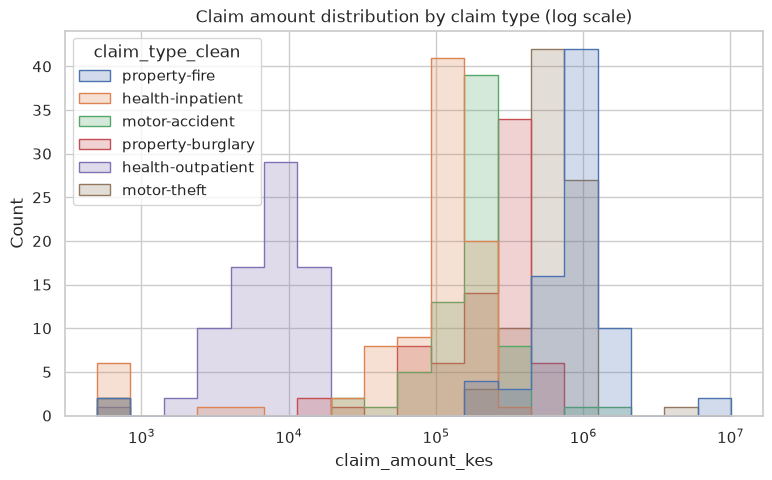

In [10]:
fig = plt.figure(figsize=(9, 5))
ax = sns.histplot(
    data=usable, x="claim_amount_kes", hue="claim_type_clean",  # hue = one colour per category
    log_scale=True, element="step", common_norm=False,
)
ax.set_title("Claim amount distribution by claim type (log scale)")
save_and_show(ax.figure, "03_seaborn_histplot_by_type.png")

Boxplots: built specifically to show outliers

saved -> plots/04_seaborn_boxplot_outliers.png


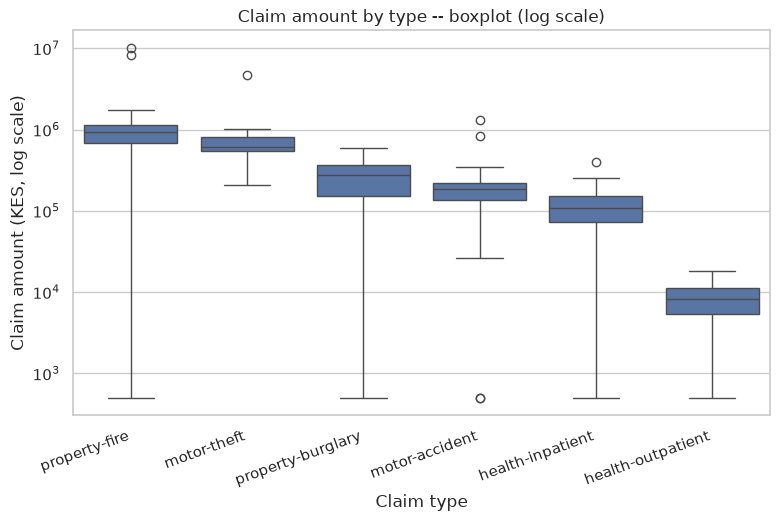

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

# Order claim types by median (highest first), purely so the chart reads
# left-to-right from biggest to smallest typical claim.
order = (
    usable.groupby("claim_type_clean")["claim_amount_kes"].median()
    .sort_values(ascending=False).index
)
sns.boxplot(data=usable, x="claim_type_clean", y="claim_amount_kes", order=order, ax=ax)
ax.set_yscale("log")
ax.set_title("Claim amount by type -- boxplot (log scale)")
ax.set_xlabel("Claim type")
ax.set_ylabel("Claim amount (KES, log scale)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")  # angle the labels so they don't overlap
save_and_show(fig, "04_seaborn_boxplot_outliers.png")

Countplots: distributions of categorical columns

Histograms and boxplots are for numbers. A countplot answers a different kind of question for categories: "how many of each do we have?" — here, claims by region and by status.

saved -> plots/05_seaborn_countplots.png


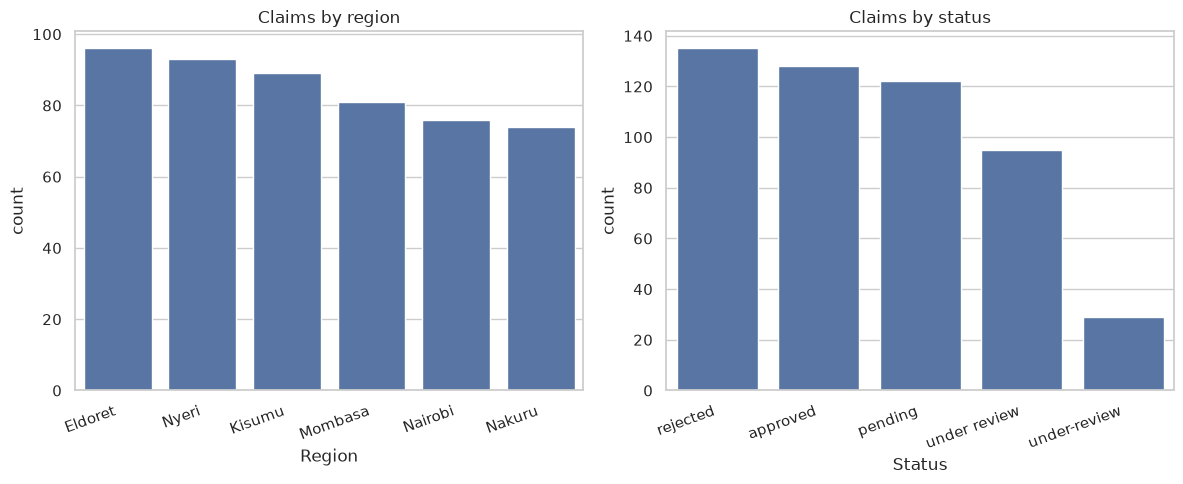

In [12]:
# Canonicalise region the same lightweight way, just for this chart.
df["region_clean"] = df["region"].astype(str).str.strip().str.title()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="region_clean", ax=axes[0],
              order=df["region_clean"].value_counts().index)
axes[0].set_title("Claims by region")
axes[0].set_xlabel("Region")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

sns.countplot(data=df, x="status_clean", ax=axes[1],
              order=df["status_clean"].value_counts().index)
axes[1].set_title("Claims by status")
axes[1].set_xlabel("Status")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

fig.tight_layout()
save_and_show(fig, "05_seaborn_countplots.png")